# Random Forest

## Imports

In [37]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

df = pd.read_csv('../../data/processed/cardio_onc_prostate_04cleaned.csv')
n_folds = 5
seed = 42

## Data Prep

In [38]:
# drop missing target
df = df[df["at_risk"].notna()].copy()

# dataset not fully numeric, but only numeric features are used for modeling
X = df.select_dtypes(include=[np.number]).drop(columns=["at_risk", "unique_patient_id"])
y = df["at_risk"].astype(int).values

print(X.shape)
print(pd.Series(y).value_counts())

(203, 44)
0    124
1     79
Name: count, dtype: int64


## Random Forest Model

In [39]:
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=300,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1
)

### Stratified K-Fold Cross Validation

In [40]:
from sklearn.model_selection import StratifiedKFold


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

results = cross_validate(
    rf,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

for metric in scoring:
    vals = results[f"test_{metric}"]
    print(f"{metric}: {vals.mean():.4f} ± {vals.std():.4f}")

precision: 0.4942 ± 0.0871
recall: 0.4542 ± 0.1024
f1: 0.4668 ± 0.0720
roc_auc: 0.6142 ± 0.0225


## Fit Final Model on Full Data

In [41]:
rf.fit(X,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

## Feature Importance

In [42]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
39,days_adt_to_nht,0.124973
0,bmi,0.083377
25,dm_noninsulin,0.082568
38,days_auth_to_start,0.071258
1,age,0.069164
6,dbp,0.054925
5,sbp,0.051840
7,bp_meds_prior,0.048788
43,prescribing_provider_enc,0.045102
40,ethnicity_enc,0.041748


In [43]:
perm_importance = permutation_importance(
    rf,
    X,
    y,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X.columns,
    "importance": perm_importance.importances_mean,
    "std": perm_importance.importances_std
}).sort_values("importance", ascending=False)

perm_df.head(15)

,feature,importance,std
25,dm_noninsulin,0.081281,0.007053
39,days_adt_to_nht,0.056650,0.011287
0,bmi,0.027586,0.006682
38,days_auth_to_start,0.024138,0.004647
7,bp_meds_prior,0.023153,0.012276
1,age,0.015271,0.008079
43,prescribing_provider_enc,0.013300,0.009360
5,sbp,0.012808,0.005485
6,dbp,0.012315,0.003972
15,lipid_panel_checked,0.012315,0.009411


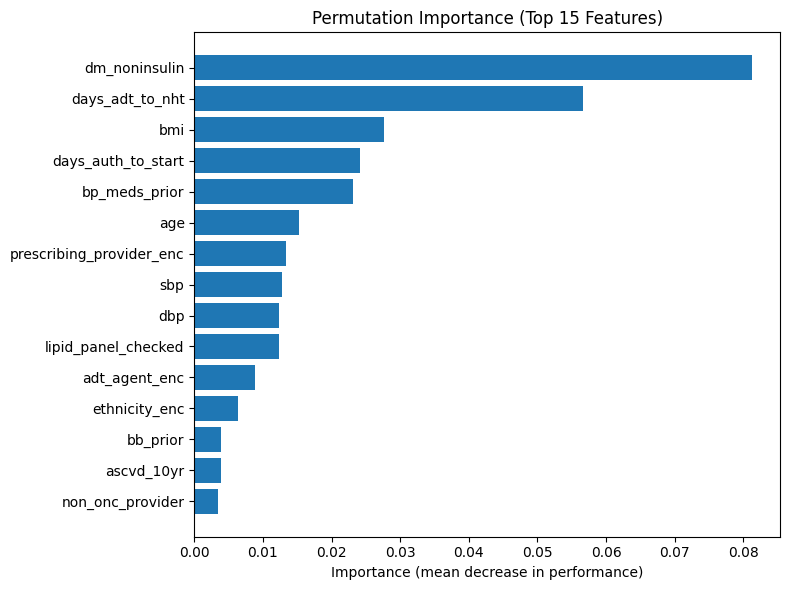

In [44]:
top15 = perm_df.head(15).sort_values("importance")

plt.figure(figsize=(8,6))
plt.barh(top15["feature"], top15["importance"])
plt.title("Permutation Importance (Top 15 Features)")
plt.xlabel("Importance (mean decrease in performance)")
plt.tight_layout()
plt.show()

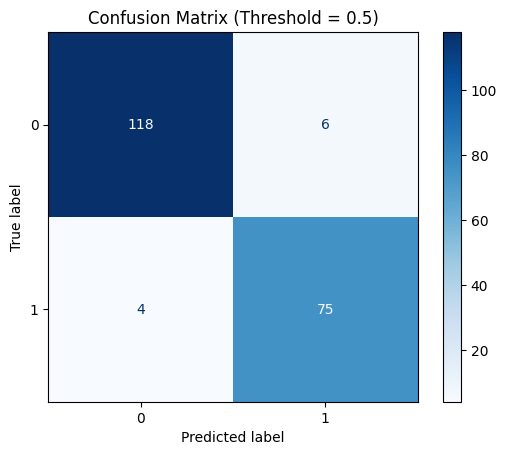

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = rf.predict(X)

cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Threshold = 0.5)")
plt.show()

In [46]:
timing_cols = [
    "days_auth_to_start",
    "days_adt_to_nht"
]

X_no_timing = X.drop(columns=timing_cols, errors="ignore")

results_no_timing = cross_validate(
    rf,
    X_no_timing,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print("\nWITH vs WITHOUT timing features:\n")

for metric in scoring:
    full = results[f"test_{metric}"].mean()
    reduced = results_no_timing[f"test_{metric}"].mean()
    print(f"{metric}: full={full:.3f}, no_timing={reduced:.3f}")


WITH vs WITHOUT timing features:

precision: full=0.494, no_timing=0.443
recall: full=0.454, no_timing=0.456
f1: full=0.467, no_timing=0.445
roc_auc: full=0.614, no_timing=0.593


## Summary

We built a Random Forest classifier to predict cardiovascular risk (at_risk) in prostate cancer patients receiving novel hormonal therapy, using structured clinical, demographic, and treatment-related variables.